In [53]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

In [54]:
data_path = Path(
    "../data/processed/clean_womens_shoes.parquet"
)

shoes = pd.read_parquet(data_path)

print("Dataset shape:", shoes.shape)
print("\nAvailable columns:")
print(shoes.columns.tolist())

shoes.head()

Dataset shape: (53176, 10)

Available columns:
['train_id', 'name', 'item_condition_id', 'category_name', 'brand_name', 'price', 'shipping', 'item_description', 'shoe_type', 'condition_group']


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,shoe_type,condition_group
0,14,HOLD for Dogs2016 Minnetonka boots,3,Women/Shoes/Boots,UGG Australia,43.0,0,Authentic. Suede fringe boots. Great condition...,Boots,Condition 3
1,70,Adidas Ultraboost Shoes,3,Women/Shoes/Athletic,Adidas,61.0,0,Overall good condition. A few signs of wear,Athletic,Condition 3
2,107,Boots NWT 6.5,1,Women/Shoes/Boots,Merona,13.0,1,Merona short boot new with tag size 6.5 come j...,Boots,Condition 1
3,108,New Duck Boots sz.7.5,1,Women/Shoes/Boots,Boulevard Boutique,38.0,0,New Duck Boots Sz.7.5 Stock up on These Trendy...,Boots,Condition 1
4,115,Steve Madden wedges,2,Women/Shoes/Pumps,Steve Madden,25.0,1,Never worn!!! Brown leather strap wedges!,Pumps,Condition 2


In [55]:
print(shoes.columns.tolist())

print("\nMissing values:")
print(shoes.isna().sum())

print("\nData types:")
print(shoes.dtypes)

['train_id', 'name', 'item_condition_id', 'category_name', 'brand_name', 'price', 'shipping', 'item_description', 'shoe_type', 'condition_group']

Missing values:
train_id             0
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
shoe_type            0
condition_group      0
dtype: int64

Data types:
train_id               int64
name                     str
item_condition_id      int64
category_name            str
brand_name               str
price                float64
shipping               int64
item_description         str
shoe_type                str
condition_group          str
dtype: object


In [56]:
print(shoes["price"].describe())

print("\nPrice percentiles:")
print(
    shoes["price"].quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

count    53176.000000
mean        40.056022
std         39.309676
min          3.000000
25%         18.000000
50%         29.000000
75%         46.000000
max        770.000000
Name: price, dtype: float64

Price percentiles:
0.50     29.0
0.75     46.0
0.90     76.0
0.95    105.0
0.99    190.0
Name: price, dtype: float64


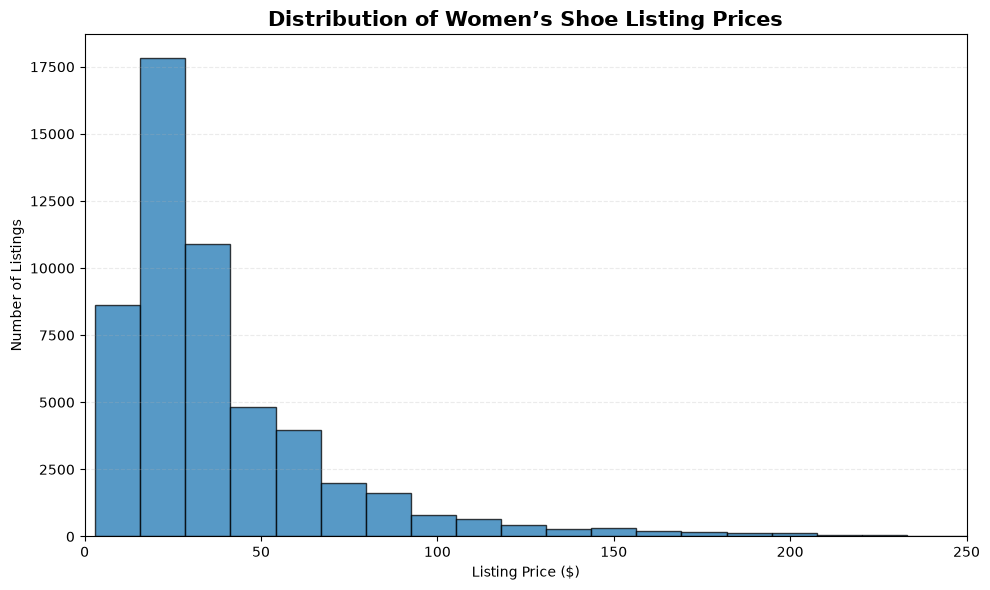

In [57]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    shoes["price"],
    bins=60,
    edgecolor="black",
    alpha=0.75
)

ax.set_title(
    "Distribution of Women’s Shoe Listing Prices",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Listing Price ($)")
ax.set_ylabel("Number of Listings")

ax.set_xlim(0, 250)
ax.grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

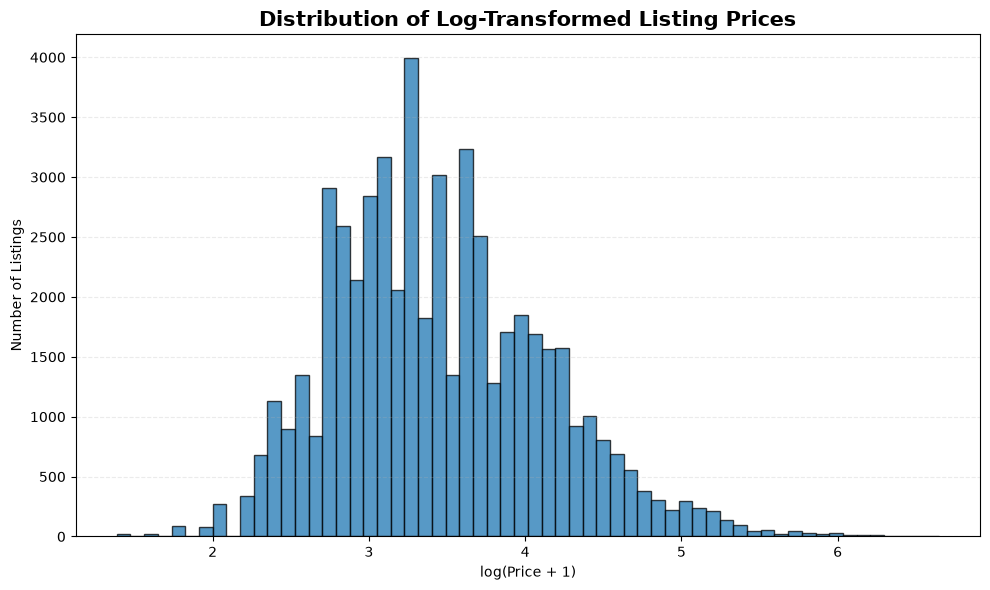

In [58]:
shoes["log_price"] = np.log1p(shoes["price"])

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    shoes["log_price"],
    bins=60,
    edgecolor="black",
    alpha=0.75
)

ax.set_title(
    "Distribution of Log-Transformed Listing Prices",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("log(Price + 1)")
ax.set_ylabel("Number of Listings")

ax.grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

In [59]:
model_columns = [
    "brand_name",
    "shoe_type",
    "item_condition_id",
    "shipping",
    "price",
    "log_price"
]

model_data = shoes[model_columns].copy()

print("Modeling dataset shape:", model_data.shape)
model_data.head()

Modeling dataset shape: (53176, 6)


,brand_name,shoe_type,item_condition_id,shipping,price,log_price
0,UGG Australia,Boots,3,0,43.0,3.784190
1,Adidas,Athletic,3,0,61.0,4.127134
2,Merona,Boots,1,1,13.0,2.639057
3,Boulevard Boutique,Boots,1,0,38.0,3.663562
4,Steve Madden,Pumps,2,1,25.0,3.258097


In [60]:
X = model_data[
    [
        "brand_name",
        "shoe_type",
        "item_condition_id"
    ]
].copy()

y = model_data["log_price"].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature shape: (53176, 3)
Target shape: (53176,)


,brand_name,shoe_type,item_condition_id
0,UGG Australia,Boots,3
1,Adidas,Athletic,3
2,Merona,Boots,1
3,Boulevard Boutique,Boots,1
4,Steve Madden,Pumps,2


In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (42540, 3)
Testing features: (10636, 3)
Training target: (42540,)
Testing target: (10636,)


In [62]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "brand_name",
    "shoe_type"
]

numeric_features = [
    "item_condition_id"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [63]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

baseline_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "regressor",
            LinearRegression()
        )
    ]
)

print("Baseline model created successfully.")

Baseline model created successfully.


In [64]:
baseline_model.fit(
    X_train,
    y_train
)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [65]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Predict log prices
predicted_log_prices = baseline_model.predict(X_test)

# Convert predictions and true values back to dollars
predicted_prices = np.expm1(predicted_log_prices)
actual_prices = np.expm1(y_test)

mae = mean_absolute_error(
    actual_prices,
    predicted_prices
)

rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        predicted_prices
    )
)

r2 = r2_score(
    actual_prices,
    predicted_prices
)

print(f"Mean Absolute Error: ${mae:.2f}")
print(f"Root Mean Squared Error: ${rmse:.2f}")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error: $14.83
Root Mean Squared Error: $30.03
R² Score: 0.450


In [66]:
median_prediction = np.full(
    shape=len(actual_prices),
    fill_value=np.median(np.expm1(y_train))
)

median_mae = mean_absolute_error(
    actual_prices,
    median_prediction
)

median_rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        median_prediction
    )
)

median_r2 = r2_score(
    actual_prices,
    median_prediction
)

print(f"Median Baseline MAE: ${median_mae:.2f}")
print(f"Median Baseline RMSE: ${median_rmse:.2f}")
print(f"Median Baseline R²: {median_r2:.3f}")

Median Baseline MAE: $21.75
Median Baseline RMSE: $41.95
Median Baseline R²: -0.073


In [67]:
model_comparison = pd.DataFrame({
    "Model": [
        "Median Baseline",
        "Linear Regression"
    ],
    "MAE": [
        median_mae,
        mae
    ],
    "RMSE": [
        median_rmse,
        rmse
    ],
    "R²": [
        median_r2,
        r2
    ]
})

model_comparison.round({
    "MAE": 2,
    "RMSE": 2,
    "R²": 3
})

,Model,MAE,RMSE,R²
0,Median Baseline,21.75,41.95,-0.073
1,Linear Regression,14.83,30.03,0.450


In [68]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "regressor",
            Ridge(alpha=1.0)
        )
    ]
)

ridge_model.fit(
    X_train,
    y_train
)

print("Ridge model trained successfully.")

Ridge model trained successfully.


In [69]:
ridge_log_predictions = ridge_model.predict(X_test)

ridge_price_predictions = np.expm1(ridge_log_predictions)

ridge_mae = mean_absolute_error(
    actual_prices,
    ridge_price_predictions
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        ridge_price_predictions
    )
)

ridge_r2 = r2_score(
    actual_prices,
    ridge_price_predictions
)

print(f"Ridge MAE: ${ridge_mae:.2f}")
print(f"Ridge RMSE: ${ridge_rmse:.2f}")
print(f"Ridge R²: {ridge_r2:.3f}")

Ridge MAE: $14.85
Ridge RMSE: $30.25
Ridge R²: 0.442


In [70]:
model_comparison = pd.DataFrame({
    "Model": [
        "Median Baseline",
        "Linear Regression",
        "Ridge Regression"
    ],
    "MAE": [
        median_mae,
        mae,
        ridge_mae
    ],
    "RMSE": [
        median_rmse,
        rmse,
        ridge_rmse
    ],
    "R²": [
        median_r2,
        r2,
        ridge_r2
    ]
})

model_comparison.round({
    "MAE": 2,
    "RMSE": 2,
    "R²": 3
})

,Model,MAE,RMSE,R²
0,Median Baseline,21.75,41.95,-0.073
1,Linear Regression,14.83,30.03,0.450
2,Ridge Regression,14.85,30.25,0.442


In [71]:
X_text = shoes[
    [
        "brand_name",
        "shoe_type",
        "item_condition_id",
        "name"
    ]
].copy()

y_text = shoes["log_price"].copy()

X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(
    X_text,
    y_text,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_text_train.shape)
print("Testing features:", X_text_test.shape)

X_text.head()

Training features: (42540, 4)
Testing features: (10636, 4)


,brand_name,shoe_type,item_condition_id,name
0,UGG Australia,Boots,3,HOLD for Dogs2016 Minnetonka boots
1,Adidas,Athletic,3,Adidas Ultraboost Shoes
2,Merona,Boots,1,Boots NWT 6.5
3,Boulevard Boutique,Boots,1,New Duck Boots sz.7.5
4,Steve Madden,Pumps,2,Steve Madden wedges


In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

text_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            [
                "brand_name",
                "shoe_type"
            ]
        ),
        (
            "numeric",
            "passthrough",
            [
                "item_condition_id"
            ]
        ),
        (
            "name_text",
            TfidfVectorizer(
                max_features=5000,
                ngram_range=(1, 2),
                min_df=2
            ),
            "name"
        )
    ]
)

print("Text preprocessor created successfully.")

Text preprocessor created successfully.


In [73]:
text_model = Pipeline(
    steps=[
        (
            "preprocessor",
            text_preprocessor
        ),
        (
            "regressor",
            Ridge(alpha=1.0)
        )
    ]
)

text_model.fit(
    X_text_train,
    y_text_train
)

print("Text-enhanced model trained successfully.")

Text-enhanced model trained successfully.


In [74]:
text_log_predictions = text_model.predict(X_text_test)

text_price_predictions = np.expm1(text_log_predictions)
text_actual_prices = np.expm1(y_text_test)

text_mae = mean_absolute_error(
    text_actual_prices,
    text_price_predictions
)

text_rmse = np.sqrt(
    mean_squared_error(
        text_actual_prices,
        text_price_predictions
    )
)

text_r2 = r2_score(
    text_actual_prices,
    text_price_predictions
)

print(f"Text Model MAE: ${text_mae:.2f}")
print(f"Text Model RMSE: ${text_rmse:.2f}")
print(f"Text Model R²: {text_r2:.3f}")

Text Model MAE: $12.65
Text Model RMSE: $26.53
Text Model R²: 0.571


In [75]:
model_comparison = pd.DataFrame({
    "Model": [
        "Median Baseline",
        "Linear Regression",
        "Ridge Regression",
        "Text-Enhanced Ridge"
    ],
    "MAE": [
        median_mae,
        mae,
        ridge_mae,
        text_mae
    ],
    "RMSE": [
        median_rmse,
        rmse,
        ridge_rmse,
        text_rmse
    ],
    "R²": [
        median_r2,
        r2,
        ridge_r2,
        text_r2
    ]
})

model_comparison.round({
    "MAE": 2,
    "RMSE": 2,
    "R²": 3
})

,Model,MAE,RMSE,R²
0,Median Baseline,21.75,41.95,-0.073
1,Linear Regression,14.83,30.03,0.450
2,Ridge Regression,14.85,30.25,0.442
3,Text-Enhanced Ridge,12.65,26.53,0.571


In [76]:
description_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            [
                "brand_name",
                "shoe_type"
            ]
        ),
        (
            "numeric",
            "passthrough",
            [
                "item_condition_id"
            ]
        ),
        (
            "name_text",
            TfidfVectorizer(
                max_features=5000,
                ngram_range=(1, 2),
                min_df=2
            ),
            "name"
        ),
        (
            "description_text",
            TfidfVectorizer(
                max_features=7500,
                ngram_range=(1, 2),
                min_df=3,
                stop_words="english"
            ),
            "item_description"
        )
    ]
)

print("Description-enhanced preprocessor created successfully.")

Description-enhanced preprocessor created successfully.


In [77]:
X_description = shoes[
    [
        "brand_name",
        "shoe_type",
        "item_condition_id",
        "name",
        "item_description"
    ]
].copy()

y_description = shoes["log_price"].copy()

X_description_train, X_description_test, y_description_train, y_description_test = train_test_split(
    X_description,
    y_description,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_description_train.shape)
print("Testing features:", X_description_test.shape)

Training features: (42540, 5)
Testing features: (10636, 5)


In [78]:
description_model = Pipeline(
    steps=[
        (
            "preprocessor",
            description_preprocessor
        ),
        (
            "regressor",
            Ridge(alpha=1.0)
        )
    ]
)

description_model.fit(
    X_description_train,
    y_description_train
)

print("Description-enhanced model trained successfully.")

Description-enhanced model trained successfully.


In [79]:
description_log_predictions = description_model.predict(
    X_description_test
)

description_price_predictions = np.expm1(
    description_log_predictions
)

description_actual_prices = np.expm1(
    y_description_test
)

description_mae = mean_absolute_error(
    description_actual_prices,
    description_price_predictions
)

description_rmse = np.sqrt(
    mean_squared_error(
        description_actual_prices,
        description_price_predictions
    )
)

description_r2 = r2_score(
    description_actual_prices,
    description_price_predictions
)

print(f"Description Model MAE: ${description_mae:.2f}")
print(f"Description Model RMSE: ${description_rmse:.2f}")
print(f"Description Model R²: {description_r2:.3f}")

Description Model MAE: $12.38
Description Model RMSE: $25.73
Description Model R²: 0.596


In [80]:
model_comparison = pd.DataFrame({
    "Model": [
        "Median Baseline",
        "Linear Regression",
        "Ridge Regression",
        "Text-Enhanced Ridge",
        "Description-Enhanced Ridge"
    ],
    "MAE": [
        median_mae,
        mae,
        ridge_mae,
        text_mae,
        description_mae
    ],
    "RMSE": [
        median_rmse,
        rmse,
        ridge_rmse,
        text_rmse,
        description_rmse
    ],
    "R²": [
        median_r2,
        r2,
        ridge_r2,
        text_r2,
        description_r2
    ]
})

model_comparison.round({
    "MAE": 2,
    "RMSE": 2,
    "R²": 3
})

,Model,MAE,RMSE,R²
0,Median Baseline,21.75,41.95,-0.073
1,Linear Regression,14.83,30.03,0.450
2,Ridge Regression,14.85,30.25,0.442
3,Text-Enhanced Ridge,12.65,26.53,0.571
4,Description-Enhanced Ridge,12.38,25.73,0.596


In [81]:
alpha_values = [0.01, 0.1, 0.5, 1, 2, 5, 10, 20]

tuning_results = []

for alpha in alpha_values:
    tuned_model = Pipeline(
        steps=[
            (
                "preprocessor",
                description_preprocessor
            ),
            (
                "regressor",
                Ridge(alpha=alpha)
            )
        ]
    )

    tuned_model.fit(
        X_description_train,
        y_description_train
    )

    tuned_log_predictions = tuned_model.predict(
        X_description_test
    )

    tuned_price_predictions = np.expm1(
        tuned_log_predictions
    )

    tuned_mae = mean_absolute_error(
        description_actual_prices,
        tuned_price_predictions
    )

    tuned_rmse = np.sqrt(
        mean_squared_error(
            description_actual_prices,
            tuned_price_predictions
        )
    )

    tuned_r2 = r2_score(
        description_actual_prices,
        tuned_price_predictions
    )

    tuning_results.append({
        "Alpha": alpha,
        "MAE": tuned_mae,
        "RMSE": tuned_rmse,
        "R²": tuned_r2
    })

tuning_results_df = pd.DataFrame(
    tuning_results
).sort_values("MAE")

tuning_results_df.round({
    "MAE": 2,
    "RMSE": 2,
    "R²": 3
})

,Alpha,MAE,RMSE,R²
5,5.00,12.22,26.08,0.585
4,2.00,12.22,25.69,0.597
3,1.00,12.38,25.73,0.596
6,10.00,12.41,26.74,0.564
2,0.50,12.63,25.98,0.588
7,20.00,12.77,27.75,0.530
1,0.10,13.29,26.91,0.558
0,0.01,13.80,27.78,0.529


In [82]:
best_model = Pipeline(
    steps=[
        (
            "preprocessor",
            description_preprocessor
        ),
        (
            "regressor",
            Ridge(alpha=2.0)
        )
    ]
)

best_model.fit(
    X_description_train,
    y_description_train
)

print("Best tuned model trained successfully.")

Best tuned model trained successfully.


In [83]:
best_log_predictions = best_model.predict(
    X_description_test
)

best_price_predictions = np.expm1(
    best_log_predictions
)

best_mae = mean_absolute_error(
    description_actual_prices,
    best_price_predictions
)

best_rmse = np.sqrt(
    mean_squared_error(
        description_actual_prices,
        best_price_predictions
    )
)

best_r2 = r2_score(
    description_actual_prices,
    best_price_predictions
)

print(f"Best Model MAE: ${best_mae:.2f}")
print(f"Best Model RMSE: ${best_rmse:.2f}")
print(f"Best Model R²: {best_r2:.3f}")

Best Model MAE: $12.22
Best Model RMSE: $25.69
Best Model R²: 0.597


In [84]:
example_listing = pd.DataFrame({
    "brand_name": ["Nike"],
    "shoe_type": ["Athletic"],
    "item_condition_id": [2],
    "name": ["Nike Air Max 270 Women's Shoes"],
    "item_description": [
        "Gently used Nike Air Max 270 shoes in good condition."
    ]
})

example_log_prediction = best_model.predict(
    example_listing
)

example_price_prediction = np.expm1(
    example_log_prediction
)

print(
    f"Predicted listing price: "
    f"${example_price_prediction[0]:.2f}"
)

Predicted listing price: $34.91


In [85]:
prediction_examples = X_description_test.copy()

prediction_examples["Actual Price"] = description_actual_prices
prediction_examples["Predicted Price"] = best_price_predictions
prediction_examples["Absolute Error"] = abs(
    prediction_examples["Actual Price"]
    - prediction_examples["Predicted Price"]
)

prediction_examples[
    [
        "brand_name",
        "shoe_type",
        "item_condition_id",
        "name",
        "Actual Price",
        "Predicted Price",
        "Absolute Error"
    ]
].sample(
    10,
    random_state=42
).round(2)

,brand_name,shoe_type,item_condition_id,name,Actual Price,Predicted Price,Absolute Error
40908,Lucky Brand,Boots,3,Teal Lucky Brand Boot • Size 8,20.0,40.99,20.99
39959,Minnetonka,Boots,3,Minnetonka Moccasin Boots,26.0,19.59,6.41
23691,Converse,Fashion Sneakers,3,Converse Chuck Taylor Shearling Boots,60.0,42.38,17.62
31967,Nike,Athletic,2,Nike Air Max Thea Rose Gold NWOT,150.0,97.84,52.16
12967,FOREVER 21,Boots,1,CHIC CLEAR THIGH HIGH BOOT (FOREVER 21),36.0,32.84,3.16
22698,UGG Australia,Boots,1,UGG classic tall women's boots,129.0,101.25,27.75
35869,UGG Australia,Boots,3,Ugg women's 6 black,21.0,35.43,14.43
50983,UGG Australia,Boots,1,New UGG Luxe Line Short Elsa Brown Boots,76.0,84.81,8.81
42263,BCBG,Sandals,2,Hi heeled platforms,15.0,19.29,4.29
49836,Converse,Fashion Sneakers,3,Converse white,19.0,23.75,4.75


In [86]:
errors = np.abs(
    description_actual_prices
    - best_price_predictions
)

print(f"Within $5:  {(errors <= 5).mean():.1%}")
print(f"Within $10: {(errors <= 10).mean():.1%}")
print(f"Within $15: {(errors <= 15).mean():.1%}")
print(f"Within $20: {(errors <= 20).mean():.1%}")

Within $5:  39.4%
Within $10: 64.2%
Within $15: 78.0%
Within $20: 85.3%


In [87]:
error_analysis = pd.DataFrame({
    "Actual Price": description_actual_prices,
    "Predicted Price": best_price_predictions
})

error_analysis["Absolute Error"] = abs(
    error_analysis["Actual Price"]
    - error_analysis["Predicted Price"]
)

error_analysis["Price Group"] = pd.cut(
    error_analysis["Actual Price"],
    bins=[0, 25, 50, 100, float("inf")],
    labels=[
        "$0–$25",
        "$25–$50",
        "$50–$100",
        "$100+"
    ],
    include_lowest=True
)

price_group_results = (
    error_analysis
    .groupby("Price Group", observed=True)
    .agg(
        Listings=("Actual Price", "size"),
        Average_Actual_Price=("Actual Price", "mean"),
        MAE=("Absolute Error", "mean")
    )
    .reset_index()
)

price_group_results.round(2)

,Price Group,Listings,Average_Actual_Price,MAE
0,$0–$25,4341,16.48,6.37
1,$25–$50,3833,34.31,8.43
2,$50–$100,1880,67.69,17.67
3,$100+,582,162.98,63.23


In [88]:
premium_keywords = [
    "limited",
    "rare",
    "vintage",
    "authentic",
    "designer",
    "luxury",
    "leather",
    "suede",
    "new",
    "nwt",
    "nwot"
]

combined_text = (
    shoes["name"].fillna("")
    + " "
    + shoes["item_description"].fillna("")
).str.lower()

for keyword in premium_keywords:
    shoes[f"has_{keyword}"] = (
        combined_text.str.contains(
            rf"\b{keyword}\b",
            regex=True
        ).astype(int)
    )

shoes["title_length"] = (
    shoes["name"]
    .fillna("")
    .str.len()
)

shoes["description_length"] = (
    shoes["item_description"]
    .fillna("")
    .str.len()
)

print("Premium indicator features created successfully.")

Premium indicator features created successfully.


In [89]:
premium_feature_columns = [
    f"has_{keyword}"
    for keyword in premium_keywords
]

X_premium = shoes[
    [
        "brand_name",
        "shoe_type",
        "item_condition_id",
        "name",
        "item_description",
        "title_length",
        "description_length"
    ]
    + premium_feature_columns
].copy()

y_premium = shoes["log_price"].copy()

X_premium_train, X_premium_test, y_premium_train, y_premium_test = train_test_split(
    X_premium,
    y_premium,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_premium_train.shape)
print("Testing features:", X_premium_test.shape)

Training features: (42540, 18)
Testing features: (10636, 18)


In [90]:
premium_numeric_features = [
    "item_condition_id",
    "title_length",
    "description_length"
] + premium_feature_columns

premium_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            [
                "brand_name",
                "shoe_type"
            ]
        ),
        (
            "numeric",
            "passthrough",
            premium_numeric_features
        ),
        (
            "name_text",
            TfidfVectorizer(
                max_features=5000,
                ngram_range=(1, 2),
                min_df=2
            ),
            "name"
        ),
        (
            "description_text",
            TfidfVectorizer(
                max_features=7500,
                ngram_range=(1, 2),
                min_df=3,
                stop_words="english"
            ),
            "item_description"
        )
    ]
)

print("Premium-feature preprocessor created successfully.")

Premium-feature preprocessor created successfully.


In [91]:
premium_model = Pipeline(
    steps=[
        (
            "preprocessor",
            premium_preprocessor
        ),
        (
            "regressor",
            Ridge(alpha=2.0)
        )
    ]
)

premium_model.fit(
    X_premium_train,
    y_premium_train
)

print("Premium-feature model trained successfully.")

Premium-feature model trained successfully.


In [92]:
premium_log_predictions = premium_model.predict(
    X_premium_test
)

premium_price_predictions = np.expm1(
    premium_log_predictions
)

premium_actual_prices = np.expm1(
    y_premium_test
)

premium_mae = mean_absolute_error(
    premium_actual_prices,
    premium_price_predictions
)

premium_rmse = np.sqrt(
    mean_squared_error(
        premium_actual_prices,
        premium_price_predictions
    )
)

premium_r2 = r2_score(
    premium_actual_prices,
    premium_price_predictions
)

print(f"Premium Model MAE: ${premium_mae:.2f}")
print(f"Premium Model RMSE: ${premium_rmse:.2f}")
print(f"Premium Model R²: {premium_r2:.3f}")

Premium Model MAE: $12.16
Premium Model RMSE: $25.46
Premium Model R²: 0.604


In [93]:
premium_error_analysis = pd.DataFrame({
    "Actual Price": premium_actual_prices,
    "Predicted Price": premium_price_predictions
})

premium_error_analysis["Absolute Error"] = abs(
    premium_error_analysis["Actual Price"]
    - premium_error_analysis["Predicted Price"]
)

premium_error_analysis["Price Group"] = pd.cut(
    premium_error_analysis["Actual Price"],
    bins=[0, 25, 50, 100, float("inf")],
    labels=[
        "$0–$25",
        "$25–$50",
        "$50–$100",
        "$100+"
    ],
    include_lowest=True
)

premium_price_group_results = (
    premium_error_analysis
    .groupby("Price Group", observed=True)
    .agg(
        Listings=("Actual Price", "size"),
        Average_Actual_Price=("Actual Price", "mean"),
        MAE=("Absolute Error", "mean")
    )
    .reset_index()
)

premium_price_group_results.round(2)

,Price Group,Listings,Average_Actual_Price,MAE
0,$0–$25,4341,16.48,6.33
1,$25–$50,3833,34.31,8.39
2,$50–$100,1880,67.69,17.61
3,$100+,582,162.98,62.79


In [94]:
training_price_groups = pd.cut(
    np.expm1(y_premium_train),
    bins=[0, 25, 50, 100, float("inf")],
    labels=[
        "$0–$25",
        "$25–$50",
        "$50–$100",
        "$100+"
    ],
    include_lowest=True
)

training_price_groups.value_counts().sort_index()

log_price
$0–$25      17076
$25–$50     15593
$50–$100     7478
$100+        2393
Name: count, dtype: int64

In [95]:
training_prices = np.expm1(y_premium_train)

sample_weights = np.where(
    training_prices > 100,
    4.0,
    np.where(
        training_prices > 50,
        2.0,
        1.0
    )
)

pd.Series(sample_weights).value_counts().sort_index()

1.0    32669
2.0     7478
4.0     2393
Name: count, dtype: int64

In [96]:
weighted_model = Pipeline(
    steps=[
        (
            "preprocessor",
            premium_preprocessor
        ),
        (
            "regressor",
            Ridge(alpha=2.0)
        )
    ]
)

weighted_model.fit(
    X_premium_train,
    y_premium_train,
    regressor__sample_weight=sample_weights
)

print("Weighted premium model trained successfully.")

Weighted premium model trained successfully.


In [97]:
weighted_log_predictions = weighted_model.predict(
    X_premium_test
)

weighted_price_predictions = np.expm1(
    weighted_log_predictions
)

weighted_mae = mean_absolute_error(
    premium_actual_prices,
    weighted_price_predictions
)

weighted_rmse = np.sqrt(
    mean_squared_error(
        premium_actual_prices,
        weighted_price_predictions
    )
)

weighted_r2 = r2_score(
    premium_actual_prices,
    weighted_price_predictions
)

print(f"Weighted Model MAE: ${weighted_mae:.2f}")
print(f"Weighted Model RMSE: ${weighted_rmse:.2f}")
print(f"Weighted Model R²: {weighted_r2:.3f}")

Weighted Model MAE: $12.39
Weighted Model RMSE: $24.43
Weighted Model R²: 0.636


In [98]:
weighted_error_analysis = pd.DataFrame({
    "Actual Price": premium_actual_prices,
    "Predicted Price": weighted_price_predictions
})

weighted_error_analysis["Absolute Error"] = abs(
    weighted_error_analysis["Actual Price"]
    - weighted_error_analysis["Predicted Price"]
)

weighted_error_analysis["Price Group"] = pd.cut(
    weighted_error_analysis["Actual Price"],
    bins=[0, 25, 50, 100, float("inf")],
    labels=[
        "$0–$25",
        "$25–$50",
        "$50–$100",
        "$100+"
    ],
    include_lowest=True
)

weighted_price_group_results = (
    weighted_error_analysis
    .groupby("Price Group", observed=True)
    .agg(
        Listings=("Actual Price", "size"),
        Average_Actual_Price=("Actual Price", "mean"),
        MAE=("Absolute Error", "mean")
    )
    .reset_index()
)

weighted_price_group_results.round(2)

,Price Group,Listings,Average_Actual_Price,MAE
0,$0–$25,4341,16.48,7.13
1,$25–$50,3833,34.31,9.52
2,$50–$100,1880,67.69,17.19
3,$100+,582,162.98,54.94


In [99]:
balanced_sample_weights = np.where(
    training_prices > 100,
    2.5,
    np.where(
        training_prices > 50,
        1.5,
        1.0
    )
)

balanced_weighted_model = Pipeline(
    steps=[
        (
            "preprocessor",
            premium_preprocessor
        ),
        (
            "regressor",
            Ridge(alpha=2.0)
        )
    ]
)

balanced_weighted_model.fit(
    X_premium_train,
    y_premium_train,
    regressor__sample_weight=balanced_sample_weights
)

print("Balanced weighted model trained successfully.")

Balanced weighted model trained successfully.


In [100]:
balanced_log_predictions = balanced_weighted_model.predict(
    X_premium_test
)

balanced_price_predictions = np.expm1(
    balanced_log_predictions
)

balanced_mae = mean_absolute_error(
    premium_actual_prices,
    balanced_price_predictions
)

balanced_rmse = np.sqrt(
    mean_squared_error(
        premium_actual_prices,
        balanced_price_predictions
    )
)

balanced_r2 = r2_score(
    premium_actual_prices,
    balanced_price_predictions
)

print(f"Balanced Weighted MAE: ${balanced_mae:.2f}")
print(f"Balanced Weighted RMSE: ${balanced_rmse:.2f}")
print(f"Balanced Weighted R²: {balanced_r2:.3f}")

Balanced Weighted MAE: $12.19
Balanced Weighted RMSE: $24.59
Balanced Weighted R²: 0.631


In [101]:
balanced_error_analysis = pd.DataFrame({
    "Actual Price": premium_actual_prices,
    "Predicted Price": balanced_price_predictions
})

balanced_error_analysis["Absolute Error"] = abs(
    balanced_error_analysis["Actual Price"]
    - balanced_error_analysis["Predicted Price"]
)

balanced_error_analysis["Price Group"] = pd.cut(
    balanced_error_analysis["Actual Price"],
    bins=[0, 25, 50, 100, float("inf")],
    labels=[
        "$0–$25",
        "$25–$50",
        "$50–$100",
        "$100+"
    ],
    include_lowest=True
)

balanced_price_group_results = (
    balanced_error_analysis
    .groupby("Price Group", observed=True)
    .agg(
        Listings=("Actual Price", "size"),
        Average_Actual_Price=("Actual Price", "mean"),
        MAE=("Absolute Error", "mean")
    )
    .reset_index()
)

balanced_price_group_results.round(2)

,Price Group,Listings,Average_Actual_Price,MAE
0,$0–$25,4341,16.48,6.80
1,$25–$50,3833,34.31,9.02
2,$50–$100,1880,67.69,17.18
3,$100+,582,162.98,57.18


In [102]:
%pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [103]:
from xgboost import XGBRegressor

print("XGBoost imported successfully.")

XGBoost imported successfully.


In [104]:
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            premium_preprocessor
        ),
        (
            "regressor",
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_model.fit(
    X_premium_train,
    y_premium_train
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [105]:
xgb_log_predictions = xgb_model.predict(
    X_premium_test
)

xgb_price_predictions = np.expm1(
    xgb_log_predictions
)

xgb_mae = mean_absolute_error(
    premium_actual_prices,
    xgb_price_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        premium_actual_prices,
        xgb_price_predictions
    )
)

xgb_r2 = r2_score(
    premium_actual_prices,
    xgb_price_predictions
)

print(f"XGBoost MAE: ${xgb_mae:.2f}")
print(f"XGBoost RMSE: ${xgb_rmse:.2f}")
print(f"XGBoost R²: {xgb_r2:.3f}")

XGBoost MAE: $13.07
XGBoost RMSE: $27.24
XGBoost R²: 0.547


In [106]:
character_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            [
                "brand_name",
                "shoe_type"
            ]
        ),
        (
            "numeric",
            "passthrough",
            premium_numeric_features
        ),
        (
            "name_words",
            TfidfVectorizer(
                max_features=5000,
                ngram_range=(1, 2),
                min_df=2
            ),
            "name"
        ),
        (
            "name_characters",
            TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(3, 5),
                max_features=7500,
                min_df=3
            ),
            "name"
        ),
        (
            "description_text",
            TfidfVectorizer(
                max_features=7500,
                ngram_range=(1, 2),
                min_df=3,
                stop_words="english"
            ),
            "item_description"
        )
    ]
)

print("Character-level preprocessor created successfully.")

Character-level preprocessor created successfully.


In [107]:
character_model = Pipeline(
    steps=[
        (
            "preprocessor",
            character_preprocessor
        ),
        (
            "regressor",
            Ridge(alpha=2.0)
        )
    ]
)

character_model.fit(
    X_premium_train,
    y_premium_train,
    regressor__sample_weight=balanced_sample_weights
)

print("Character-enhanced model trained successfully.")

Character-enhanced model trained successfully.


In [108]:
character_log_predictions = character_model.predict(
    X_premium_test
)

character_price_predictions = np.expm1(
    character_log_predictions
)

character_mae = mean_absolute_error(
    premium_actual_prices,
    character_price_predictions
)

character_rmse = np.sqrt(
    mean_squared_error(
        premium_actual_prices,
        character_price_predictions
    )
)

character_r2 = r2_score(
    premium_actual_prices,
    character_price_predictions
)

print(f"Character Model MAE: ${character_mae:.2f}")
print(f"Character Model RMSE: ${character_rmse:.2f}")
print(f"Character Model R²: {character_r2:.3f}")

Character Model MAE: $12.15
Character Model RMSE: $24.28
Character Model R²: 0.640


In [109]:
character_error_analysis = pd.DataFrame({
    "Actual Price": premium_actual_prices,
    "Predicted Price": character_price_predictions
})

character_error_analysis["Absolute Error"] = abs(
    character_error_analysis["Actual Price"]
    - character_error_analysis["Predicted Price"]
)

character_error_analysis["Price Group"] = pd.cut(
    character_error_analysis["Actual Price"],
    bins=[0, 25, 50, 100, float("inf")],
    labels=[
        "$0–$25",
        "$25–$50",
        "$50–$100",
        "$100+"
    ],
    include_lowest=True
)

character_price_group_results = (
    character_error_analysis
    .groupby("Price Group", observed=True)
    .agg(
        Listings=("Actual Price", "size"),
        Average_Actual_Price=("Actual Price", "mean"),
        MAE=("Absolute Error", "mean")
    )
    .reset_index()
)

character_price_group_results.round(2)

,Price Group,Listings,Average_Actual_Price,MAE
0,$0–$25,4341,16.48,6.80
1,$25–$50,3833,34.31,9.03
2,$50–$100,1880,67.69,17.26
3,$100+,582,162.98,56.06
